# Processioning

Der Alpha Algorithmus ist [hier](#Alpha-Algorithmus) (hoffendlich, ansonsten runter scrollen)




In [33]:
using System.IO;
using System.Globalization;


record Data(
    int Id,
    string CustomerId, 
    string TransactionId, 
    string ActionType,
    int StatusCode, 
    string UserId,
    DateTime TimestampStart,
    DateTime TimestampEnd, 
    string PriorityLevel,
    int ResponseTime,
    string Notes,
    bool Cleaned = false);

var data = File.ReadAllLines("customer_request_system_log.csv")
    .Skip(1)
    .Select(x => {
        var cells = x.Split(',');
        return new Data(
            int.Parse(cells[0]),
            cells[1],
            cells[2],
            cells[3],
            int.Parse(cells[4]),
            cells[5],
            DateTime.ParseExact(cells[6], "yyyy-MM-dd HH:mm:ss", CultureInfo.InvariantCulture),
            DateTime.ParseExact(cells[7], "yyyy-MM-dd HH:mm:ss", CultureInfo.InvariantCulture),
            cells[8],
            int.Parse(cells[9]),
            cells[10]
        );
    } )
    .OrderBy(x => x.TimestampStart)
    .ToList();



In [34]:
data

index value 0 Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = Fals... Id 1001 CustomerId CUST-001 TransactionId REQ-001 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:00:00Z TimestampEnd 2025-01-01 09:01:30Z PriorityLevel HIGH ResponseTime 90 Notes Initial entry for customer inquiry Cleaned False 1 Data { Id = 1002, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = DATA_INPUT, StatusCode = 200, UserId = USR-B, TimestampStart = 1/1/2025 9:15:00 AM, TimestampEnd = 1/1/2025 9:20:00 AM, PriorityLevel = MEDIUM, ResponseTime = 300, Notes = Customer details entered, Cleaned = False } Id 1002 CustomerId CUST-002 TransactionId REQ-002 ActionType DATA_INPUT StatusCode 200 UserId USR-B TimestampStart 2025-01-01 09:15:00Z TimestampEnd 2025-01-01 09:20:00Z PriorityLevel MEDIUM ResponseTime 300 Notes Customer details entered Cleaned False 2 Data { Id = 1003, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = VALIDATE_DATA, StatusCode = 200, UserId = USR-C, TimestampStart = 1/1/2025 9:25:00 AM, TimestampEnd = 1/1/2025 9:27:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Data validated and passed, Cleaned = False } Id 1003 CustomerId CUST-001 TransactionId REQ-001 ActionType VALIDATE_DATA StatusCode 200 UserId USR-C TimestampStart 2025-01-01 09:25:00Z TimestampEnd 2025-01-01 09:27:00Z PriorityLevel HIGH ResponseTime 120 Notes Data validated and passed Cleaned False 3 Data { Id = 1004, CustomerId = CUST-003, TransactionId = REQ-003, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:30:00 AM, TimestampEnd = 1/1/2025 9:32:00 AM, PriorityLevel = LOW, ResponseTime = 120, Notes = New request created, Cleaned = False } Id 1004 CustomerId CUST-003 TransactionId REQ-003 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:30:00Z TimestampEnd 2025-01-01 09:32:00Z PriorityLevel LOW ResponseTime 120 Notes New request created Cleaned False 4 Data { Id = 1005, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = CHECK_RULES, StatusCode = 200, UserId = USR-D, TimestampStart = 1/1/2025 9:40:00 AM, TimestampEnd = 1/1/2025 9:45:00 AM, PriorityLevel = MEDIUM, ResponseTime = 300, Notes = Policy rules checked, Cleaned = False } Id 1005 CustomerId CUST-002 TransactionId REQ-002 ActionType CHECK_RULES StatusCode 200 UserId USR-D TimestampStart 2025-01-01 09:40:00Z TimestampEnd 2025-01-01 09:45:00Z PriorityLevel MEDIUM ResponseTime 300 Notes Policy rules checked Cleaned False 5 Data { Id = 1006, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = DECIDE_ACTION, StatusCode = 200, UserId = USR-E, TimestampStart = 1/1/2025 9:50:00 AM, TimestampEnd = 1/1/2025 9:52:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Decision made: approve, Cleaned = False } Id 1006 CustomerId CUST-001 TransactionId REQ-001 ActionType DECIDE_ACTION StatusCode 200 UserId USR-E TimestampStart 2025-01-01 09:50:00Z TimestampEnd 2025-01-01 09:52:00Z PriorityLevel HIGH ResponseTime 120 Notes Decision made: approve Cleaned False 6 Data { Id = 1007, CustomerId = REQ-004, TransactionId = CUST-004, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 10:00:00 AM, TimestampEnd = 1/1/2025 10:02:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Urgent new request, Cleaned = False } Id 1007 CustomerId REQ-004 TransactionId CUST-004 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 10:00:00Z TimestampEnd 2025-01-01 10:02:00Z PriorityLevel HIGH ResponseTime 120 Notes Urgent new request Cleaned False 7 Data { Id = 1009, CustomerId = REQ-003, TransactionId = CUST-003, ActionType = VALIDATE_DATA, StatusCode = 404, UserId = USR-C, TimestampStart =

In [35]:
data.GroupBy(x => x.CustomerId)

index value 0 [ Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = False }, Data { Id = 1003, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = VALIDATE_DATA, StatusCode = 200, UserId = USR-C, TimestampStart = 1/1/2025 9:25:00 AM, TimestampEnd = 1/1/2025 9:27:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Data validated and passed, Cleaned = False }, Data { Id = 1006, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = DECIDE_ACTION, StatusCode = 200, UserId = USR-E, TimestampStart = 1/1/2025 9:50:00 AM, TimestampEnd = 1/1/2025 9:52:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Decision made: approve, Cleaned = False }, Data { Id = 1013, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CLOSE_CASE, StatusCode = 200, UserId = USR-I, TimestampStart = 1/1/2025 10:50:00 AM, TimestampEnd = 1/1/2025 10:50:45 AM, PriorityLevel = HIGH, ResponseTime = 45, Notes = Case closed successfully, Cleaned = False } ] Key CUST-001 (values) index value 0 Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = Fals... Id 1001 CustomerId CUST-001 TransactionId REQ-001 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:00:00Z TimestampEnd 2025-01-01 09:01:30Z PriorityLevel HIGH ResponseTime 90 Notes Initial entry for customer inquiry Cleaned False 1 Data { Id = 1003, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = VALIDATE_DATA, StatusCode = 200, UserId = USR-C, TimestampStart = 1/1/2025 9:25:00 AM, TimestampEnd = 1/1/2025 9:27:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Data validated and passed, Cleaned = False } Id 1003 CustomerId CUST-001 TransactionId REQ-001 ActionType VALIDATE_DATA StatusCode 200 UserId USR-C TimestampStart 2025-01-01 09:25:00Z TimestampEnd 2025-01-01 09:27:00Z PriorityLevel HIGH ResponseTime 120 Notes Data validated and passed Cleaned False 2 Data { Id = 1006, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = DECIDE_ACTION, StatusCode = 200, UserId = USR-E, TimestampStart = 1/1/2025 9:50:00 AM, TimestampEnd = 1/1/2025 9:52:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Decision made: approve, Cleaned = False } Id 1006 CustomerId CUST-001 TransactionId REQ-001 ActionType DECIDE_ACTION StatusCode 200 UserId USR-E TimestampStart 2025-01-01 09:50:00Z TimestampEnd 2025-01-01 09:52:00Z PriorityLevel HIGH ResponseTime 120 Notes Decision made: approve Cleaned False 3 Data { Id = 1013, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CLOSE_CASE, StatusCode = 200, UserId = USR-I, TimestampStart = 1/1/2025 10:50:00 AM, TimestampEnd = 1/1/2025 10:50:45 AM, PriorityLevel = HIGH, ResponseTime = 45, Notes = Case closed successfully, Cleaned = False } Id 1013 CustomerId CUST-001 TransactionId REQ-001 ActionType CLOSE_CASE StatusCode 200 UserId USR-I TimestampStart 2025-01-01 10:50:00Z TimestampEnd 2025-01-01 10:50:45Z PriorityLevel HIGH ResponseTime 45 Notes Case closed successfully Cleaned False 1 [ Data { Id = 1002, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = DATA_INPUT, StatusCode = 200, UserId = USR-B, TimestampStart = 1/1/2025 9:15:00 AM, TimestampEnd = 1/1/2025 9:20:00 AM, PriorityLevel = MEDIUM, ResponseTime = 300, Notes = Customer details entered, Cleaned = False }, Data { Id = 1005, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = CHECK_RULES, StatusCode = 200, UserId = USR-D, TimestampStart = 1/1/2025 9:40:00 AM, TimestampEnd = 1/1/2025 9:45:00 AM, PriorityLevel = MEDIUM, ResponseTime = 3

In [36]:
data.GroupBy(x => x.UserId)

index value 0 [ Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = False }, Data { Id = 1004, CustomerId = CUST-003, TransactionId = REQ-003, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:30:00 AM, TimestampEnd = 1/1/2025 9:32:00 AM, PriorityLevel = LOW, ResponseTime = 120, Notes = New request created, Cleaned = False }, Data { Id = 1007, CustomerId = REQ-004, TransactionId = CUST-004, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 10:00:00 AM, TimestampEnd = 1/1/2025 10:02:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Urgent new request, Cleaned = False }, Data { Id = 1012, CustomerId = REQ-003, TransactionId = CUST-003, ActionType = REVISE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 10:40:00 AM, TimestampEnd = 1/1/2025 10:42:00 AM, PriorityLevel = LOW, ResponseTime = 120, Notes = Entry revised after validation failure, Cleaned = False }, Data { Id = 1023, CustomerId = CUST-005, TransactionId = REQ-005, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 12:10:00 PM, TimestampEnd = 1/1/2025 12:12:00 PM, PriorityLevel = MEDIUM, ResponseTime = 120, Notes = New entry, Cleaned = False }, Data { Id = 1026, CustomerId = REQ-005, TransactionId = CUST-005, ActionType = REVISE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 12:40:00 PM, TimestampEnd = 1/1/2025 12:42:00 PM, PriorityLevel = MEDIUM, ResponseTime = 120, Notes = Revised, Cleaned = False }, Data { Id = 1028, CustomerId = REQ-005, TransactionId = CUST-005, ActionType = REVISE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 1:00:00 PM, TimestampEnd = 1/1/2025 1:02:00 PM, PriorityLevel = MEDIUM, ResponseTime = 120, Notes = Second revision, Cleaned = False } ] Key USR-A (values) index value 0 Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = Fals... Id 1001 CustomerId CUST-001 TransactionId REQ-001 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:00:00Z TimestampEnd 2025-01-01 09:01:30Z PriorityLevel HIGH ResponseTime 90 Notes Initial entry for customer inquiry Cleaned False 1 Data { Id = 1004, CustomerId = CUST-003, TransactionId = REQ-003, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:30:00 AM, TimestampEnd = 1/1/2025 9:32:00 AM, PriorityLevel = LOW, ResponseTime = 120, Notes = New request created, Cleaned = False } Id 1004 CustomerId CUST-003 TransactionId REQ-003 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:30:00Z TimestampEnd 2025-01-01 09:32:00Z PriorityLevel LOW ResponseTime 120 Notes New request created Cleaned False 2 Data { Id = 1007, CustomerId = REQ-004, TransactionId = CUST-004, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 10:00:00 AM, TimestampEnd = 1/1/2025 10:02:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Urgent new request, Cleaned = False } Id 1007 CustomerId REQ-004 TransactionId CUST-004 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 10:00:00Z TimestampEnd 2025-01-01 10:02:00Z PriorityLevel HIGH ResponseTime 120 Notes Urgent new request Cleaned False 3 Data { Id = 1012, CustomerId = REQ-003, TransactionId = CUST-003, ActionType = REVISE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 10:40:00 AM, TimestampEnd = 1/1/2025 10:42:00 AM, PriorityLevel = LOW, ResponseTime = 120, Notes

In [37]:
data.GroupBy(x => x.TransactionId)

index value 0 [ Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = False }, Data { Id = 1003, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = VALIDATE_DATA, StatusCode = 200, UserId = USR-C, TimestampStart = 1/1/2025 9:25:00 AM, TimestampEnd = 1/1/2025 9:27:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Data validated and passed, Cleaned = False }, Data { Id = 1006, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = DECIDE_ACTION, StatusCode = 200, UserId = USR-E, TimestampStart = 1/1/2025 9:50:00 AM, TimestampEnd = 1/1/2025 9:52:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Decision made: approve, Cleaned = False }, Data { Id = 1013, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CLOSE_CASE, StatusCode = 200, UserId = USR-I, TimestampStart = 1/1/2025 10:50:00 AM, TimestampEnd = 1/1/2025 10:50:45 AM, PriorityLevel = HIGH, ResponseTime = 45, Notes = Case closed successfully, Cleaned = False } ] Key REQ-001 (values) index value 0 Data { Id = 1001, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CREATE_ENTRY, StatusCode = 200, UserId = USR-A, TimestampStart = 1/1/2025 9:00:00 AM, TimestampEnd = 1/1/2025 9:01:30 AM, PriorityLevel = HIGH, ResponseTime = 90, Notes = Initial entry for customer inquiry, Cleaned = Fals... Id 1001 CustomerId CUST-001 TransactionId REQ-001 ActionType CREATE_ENTRY StatusCode 200 UserId USR-A TimestampStart 2025-01-01 09:00:00Z TimestampEnd 2025-01-01 09:01:30Z PriorityLevel HIGH ResponseTime 90 Notes Initial entry for customer inquiry Cleaned False 1 Data { Id = 1003, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = VALIDATE_DATA, StatusCode = 200, UserId = USR-C, TimestampStart = 1/1/2025 9:25:00 AM, TimestampEnd = 1/1/2025 9:27:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Data validated and passed, Cleaned = False } Id 1003 CustomerId CUST-001 TransactionId REQ-001 ActionType VALIDATE_DATA StatusCode 200 UserId USR-C TimestampStart 2025-01-01 09:25:00Z TimestampEnd 2025-01-01 09:27:00Z PriorityLevel HIGH ResponseTime 120 Notes Data validated and passed Cleaned False 2 Data { Id = 1006, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = DECIDE_ACTION, StatusCode = 200, UserId = USR-E, TimestampStart = 1/1/2025 9:50:00 AM, TimestampEnd = 1/1/2025 9:52:00 AM, PriorityLevel = HIGH, ResponseTime = 120, Notes = Decision made: approve, Cleaned = False } Id 1006 CustomerId CUST-001 TransactionId REQ-001 ActionType DECIDE_ACTION StatusCode 200 UserId USR-E TimestampStart 2025-01-01 09:50:00Z TimestampEnd 2025-01-01 09:52:00Z PriorityLevel HIGH ResponseTime 120 Notes Decision made: approve Cleaned False 3 Data { Id = 1013, CustomerId = CUST-001, TransactionId = REQ-001, ActionType = CLOSE_CASE, StatusCode = 200, UserId = USR-I, TimestampStart = 1/1/2025 10:50:00 AM, TimestampEnd = 1/1/2025 10:50:45 AM, PriorityLevel = HIGH, ResponseTime = 45, Notes = Case closed successfully, Cleaned = False } Id 1013 CustomerId CUST-001 TransactionId REQ-001 ActionType CLOSE_CASE StatusCode 200 UserId USR-I TimestampStart 2025-01-01 10:50:00Z TimestampEnd 2025-01-01 10:50:45Z PriorityLevel HIGH ResponseTime 45 Notes Case closed successfully Cleaned False 1 [ Data { Id = 1002, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = DATA_INPUT, StatusCode = 200, UserId = USR-B, TimestampStart = 1/1/2025 9:15:00 AM, TimestampEnd = 1/1/2025 9:20:00 AM, PriorityLevel = MEDIUM, ResponseTime = 300, Notes = Customer details entered, Cleaned = False }, Data { Id = 1005, CustomerId = CUST-002, TransactionId = REQ-002, ActionType = CHECK_RULES, StatusCode = 200, UserId = USR-D, TimestampStart = 1/1/2025 9:40:00 AM, TimestampEnd = 1/1/2025 9:45:00 AM, PriorityLevel = MEDIUM, ResponseTime = 30

# Actions

**Aktivität**
Eine Aktivität besteht aus "action_type" und "status_code". Daraus ergeben sich 7 actions von denen eine fehlschlagen kann, was insgesamt 8 Aktivitäten macht.
Die anderen Spalten stellen keine Aktivität dar, sondern spezifizieren Details einer Aktivität.
Eg:
 * Die gleich Aktivität kann für verschiedene User durchgeführt werden
 * Die gleiche Aktivität kann unterschiedliche Details (Notes) haben

**CaseID**
Die CaseId ist die Numer in der CustomerID, die sich entweder in der customer oder Transaction spalte befindet

**TimeStamp**
```timestamp_start``` ist die Timestamp. Es ist üblich die startzeit als Timestamp anzugeben. Die Endzeit kann nicht zusätzlich verwendet werden, weil ein Zeitpunkt und keine Zeitspanne gefragt ist.

## Gruppieren der Aktionen
Kombinieren von action und status

In [38]:
var actionGroups = data.GroupBy(x => (x.ActionType, x.StatusCode))
    .Select(x => ($"{x.Key.ActionType}_{(x.Key.StatusCode == 200 ? "SUCCESS" : "FAILED")}", x.ToList()))
    .ToList();

actionGroups.Select(x => x.Item1)

[ CREATE_ENTRY_SUCCESS, DATA_INPUT_SUCCESS, VALIDATE_DATA_SUCCESS, CHECK_RULES_SUCCESS, DECIDE_ACTION_SUCCESS, VALIDATE_DATA_FAILED, REVISE_ENTRY_SUCCESS, CLOSE_CASE_SUCCESS ]

## Erzeugen der Xes Daten

In [39]:
record XesGroup(int CaseId, string Activity, DateTime Timestamp);

int GetCaseId(Data d) {

    var idString = d.CustomerId.StartsWith("CUST-") ? d.CustomerId : d.TransactionId;
    return int.Parse(idString[5..]);
}

var xes = data.Select(x => new XesGroup(
    GetCaseId(x), $"{x.ActionType}_{(x.StatusCode == 200 ? "SUCCESS" : "FAILED")}", 
    x.TimestampStart))
    .OrderBy(x => x.Timestamp)
    .ThenBy(x => x.CaseId);

var xes2 = data.Select(x => new XesGroup(
    GetCaseId(x), $"{x.ActionType}_{(x.StatusCode == 200 ? "SUCCESS" : "FAILED")}", 
    x.TimestampStart))
    .OrderBy(x => x.CaseId)
    .ThenBy(x => x.Timestamp);


xes

index value 0 XesGroup { CaseId = 1, Activity = CREATE_ENTRY_SUCCESS, Timestamp = 1/1/2025 9:00:00 AM } CaseId 1 Activity CREATE_ENTRY_SUCCESS Timestamp 2025-01-01 09:00:00Z 1 XesGroup { CaseId = 2, Activity = DATA_INPUT_SUCCESS, Timestamp = 1/1/2025 9:15:00 AM } CaseId 2 Activity DATA_INPUT_SUCCESS Timestamp 2025-01-01 09:15:00Z 2 XesGroup { CaseId = 1, Activity = VALIDATE_DATA_SUCCESS, Timestamp = 1/1/2025 9:25:00 AM } CaseId 1 Activity VALIDATE_DATA_SUCCESS Timestamp 2025-01-01 09:25:00Z 3 XesGroup { CaseId = 3, Activity = CREATE_ENTRY_SUCCESS, Timestamp = 1/1/2025 9:30:00 AM } CaseId 3 Activity CREATE_ENTRY_SUCCESS Timestamp 2025-01-01 09:30:00Z 4 XesGroup { CaseId = 2, Activity = CHECK_RULES_SUCCESS, Timestamp = 1/1/2025 9:40:00 AM } CaseId 2 Activity CHECK_RULES_SUCCESS Timestamp 2025-01-01 09:40:00Z 5 XesGroup { CaseId = 1, Activity = DECIDE_ACTION_SUCCESS, Timestamp = 1/1/2025 9:50:00 AM } CaseId 1 Activity DECIDE_ACTION_SUCCESS Timestamp 2025-01-01 09:50:00Z 6 XesGroup { CaseId = 4, Activity = CREATE_ENTRY_SUCCESS, Timestamp = 1/1/2025 10:00:00 AM } CaseId 4 Activity CREATE_ENTRY_SUCCESS Timestamp 2025-01-01 10:00:00Z 7 XesGroup { CaseId = 3, Activity = VALIDATE_DATA_FAILED, Timestamp = 1/1/2025 10:15:00 AM } CaseId 3 Activity VALIDATE_DATA_FAILED Timestamp 2025-01-01 10:15:00Z 8 XesGroup { CaseId = 3, Activity = REVISE_ENTRY_SUCCESS, Timestamp = 1/1/2025 10:40:00 AM } CaseId 3 Activity REVISE_ENTRY_SUCCESS Timestamp 2025-01-01 10:40:00Z 9 XesGroup { CaseId = 1, Activity = CLOSE_CASE_SUCCESS, Timestamp = 1/1/2025 10:50:00 AM } CaseId 1 Activity CLOSE_CASE_SUCCESS Timestamp 2025-01-01 10:50:00Z 10 XesGroup { CaseId = 4, Activity = DATA_INPUT_SUCCESS, Timestamp = 1/1/2025 11:00:00 AM } CaseId 4 Activity DATA_INPUT_SUCCESS Timestamp 2025-01-01 11:00:00Z 11 XesGroup { CaseId = 3, Activity = VALIDATE_DATA_SUCCESS, Timestamp = 1/1/2025 11:10:00 AM } CaseId 3 Activity VALIDATE_DATA_SUCCESS Timestamp 2025-01-01 11:10:00Z 12 XesGroup { CaseId = 4, Activity = CHECK_RULES_SUCCESS, Timestamp = 1/1/2025 11:15:00 AM } CaseId 4 Activity CHECK_RULES_SUCCESS Timestamp 2025-01-01 11:15:00Z 13 XesGroup { CaseId = 3, Activity = DECIDE_ACTION_SUCCESS, Timestamp = 1/1/2025 11:25:00 AM } CaseId 3 Activity DECIDE_ACTION_SUCCESS Timestamp 2025-01-01 11:25:00Z 14 XesGroup { CaseId = 4, Activity = DECIDE_ACTION_SUCCESS, Timestamp = 1/1/2025 11:30:00 AM } CaseId 4 Activity DECIDE_ACTION_SUCCESS Timestamp 2025-01-01 11:30:00Z 15 XesGroup { CaseId = 3, Activity = CLOSE_CASE_SUCCESS, Timestamp = 1/1/2025 11:55:00 AM } CaseId 3 Activity CLOSE_CASE_SUCCESS Timestamp 2025-01-01 11:55:00Z 16 XesGroup { CaseId = 4, Activity = CLOSE_CASE_SUCCESS, Timestamp = 1/1/2025 12:00:00 PM } CaseId 4 Activity CLOSE_CASE_SUCCESS Timestamp 2025-01-01 12:00:00Z 17 XesGroup { CaseId = 5, Activity = CREATE_ENTRY_SUCCESS, Timestamp = 1/1/2025 12:10:00 PM } CaseId 5 Activity CREATE_ENTRY_SUCCESS Timestamp 2025-01-01 12:10:00Z 18 XesGroup { CaseId = 5, Activity = DATA_INPUT_SUCCESS, Timestamp = 1/1/2025 12:20:00 PM } CaseId 5 Activity DATA_INPUT_SUCCESS Timestamp 2025-01-01 12:20:00Z 19 XesGroup { CaseId = 5, Activity = VALIDATE_DATA_FAILED, Timestamp = 1/1/2025 12:30:00 PM } CaseId 5 Activity VALIDATE_DATA_FAILED Timestamp 2025-01-01 12:30:00Z ... (more)

In [40]:
File.WriteAllLines("xes.csv", xes.Select(x => $"{x.CaseId},{x.Activity},{x.Timestamp:yyyy-MM-dd HH:mm:ss}"));
File.WriteAllLines("xes2.csv", xes2.Select(x => $"{x.CaseId},{x.Activity},{x.Timestamp:yyyy-MM-dd HH:mm:ss}"));

# Alpha-Algorithmus (manuell)


 * create -> validateS -> decide -> close
 * input -> check
 * create -> validateF -> revise -> validateS -> decide -> close
 * create -> input -> check -> decide -> close
 * create -> input -> validateF -> revise -> validateF -> revise -> decide -> close


CREATE_ENTRY_SUCCESS, DATA_INPUT_SUCCESS, VALIDATE_DATA_SUCCESS, CHECK_RULES_SUCCESS, DECIDE_ACTION_SUCCESS, VALIDATE_DATA_FAILED, REVISE_ENTRY_SUCCESS, CLOSE_CASE_SUCCESS

## Matrix

|           | create | input | validateS | check | decide | validateF | revise | close |
| --------- | ------ | ----- | --------- | ----- | ------ | --------- | ------ | ----- |
| create    | #      | ->    | ->        | #     | #      | ->        | #      | #     |
| input     | <-     | #     | #         | ->    | #      | ->        | #      | #     |
| validateS | <-     | #     | #         | #     | ->     | #         | <-     | #     |
| check     | #      | <-    | #         | #     | ->     | #         | #      | #     |
| decide    | #      | #     | <-        | <-    | #      | #         | <-     | ->    |
| validateF | <-     | <-    | #         | #     | #      | #         | <->    | #     |
| revise    | #      | #     | ->        | #     | ->     | <->       | #      | #     |
| close     | #      | #     | #         | #     | <-     | #         | #      | #     |


* ({create}, {input})
* ({create}, {validateS})
* ({create}, {validateF})
* ({input}, {check})
* ({input}, {validateF})
* ({validateS}, {decide})
* ({check}, {close})
* ({decide}, {close})
* ({revise}, {validateS})
* ({revise}, {decide})

*Im Beispiel werden (scheinbar ohne muster) Aktivitäten als mengen zusammengefasst. Also mache ich das auch...
**Start:**
+ ({create}, {input, validateS, validateF}) -> p1
+ ({input}, {check, validateF}) -> p2

**??**
+ ({validateS}, {decide}) -> p3
+ ({revise}, {validateS, decide}) -> p6
  
+ ({create, revise}, {validateS}) -> p7
+ ({validateS, revised}, {decide}) -> p9
  
**End:**
+ ({input}, {check}) -> p10
+ ({check, decide}, {close}) -> p11

## Petri-Netz

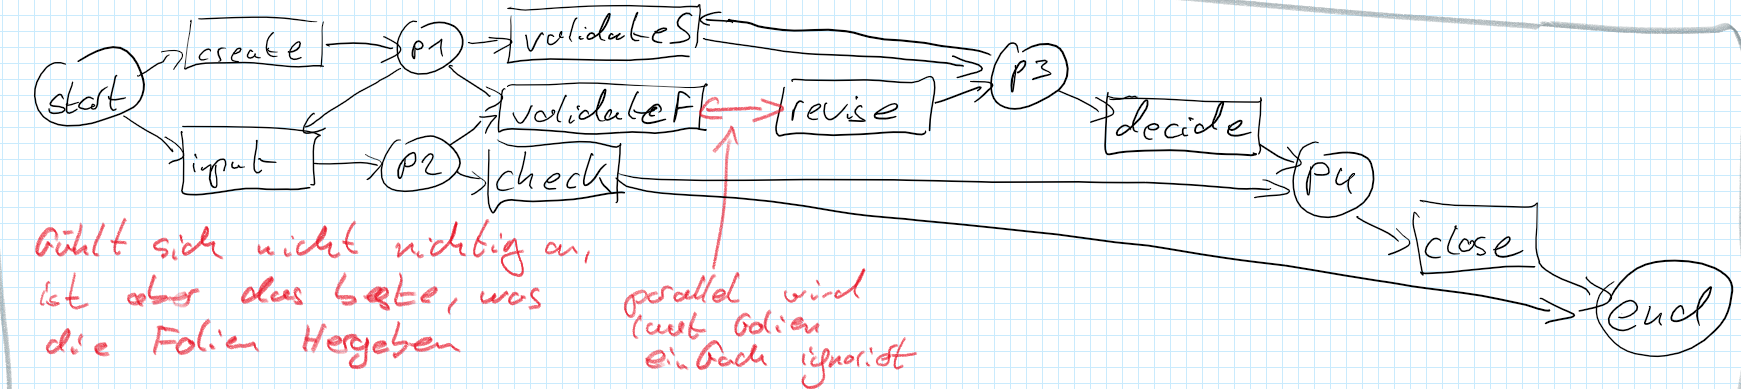

# Alpha-Algorithmus

Da ich erst am Abend Gesehen habe, dass wir noch die Implementierungsaufgabe haben und ich eine Abneigung gegen Python als auch gegen Java habe, gibt es die Implementierung jetzt in einem C# Notebook. Außerdem habe ich für die andere Praktikumsabgabe dieses notebook bereits angefangen.

Um dieses Notebook zu benutzen brauchst du vscode mit der Notebooks extension und eine aktuelle dotnet sdk


In [41]:

// Get the unique activities from the xes log
var uniqueActivities = xes.Select(x => x.Activity).Distinct().ToList();
uniqueActivities


[ CREATE_ENTRY_SUCCESS, DATA_INPUT_SUCCESS, VALIDATE_DATA_SUCCESS, CHECK_RULES_SUCCESS, DECIDE_ACTION_SUCCESS, VALIDATE_DATA_FAILED, REVISE_ENTRY_SUCCESS, CLOSE_CASE_SUCCESS ]

## Causalities

 ### -> L

In [42]:

// Nachfolgen

// Group all cases together
var edges = xes.GroupBy(x => x.CaseId)
// Zipping everything but the last together with everything but the first result in a list of tuples containing the successors
    .Select(c => c.SkipLast(1).Zip(c.Skip(1)))
// Unpack the groups and the tuple to only return the actions
    .SelectMany(x => x.Select(y => (y.Item1.Activity, y.Item2.Activity)))
// Only distinct tuples. We don't care about duplicates
    .Distinct()
    .ToList();
edges

// Dies resultiert in den Folgenden Beziehungen (a -> b):

index value 0 (CREATE_ENTRY_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 VALIDATE_DATA_SUCCESS 1 (VALIDATE_DATA_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 DECIDE_ACTION_SUCCESS 2 (DECIDE_ACTION_SUCCESS, CLOSE_CASE_SUCCESS) Item1 DECIDE_ACTION_SUCCESS Item2 CLOSE_CASE_SUCCESS 3 (DATA_INPUT_SUCCESS, CHECK_RULES_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 CHECK_RULES_SUCCESS 4 (CREATE_ENTRY_SUCCESS, VALIDATE_DATA_FAILED) Item1 CREATE_ENTRY_SUCCESS Item2 VALIDATE_DATA_FAILED 5 (VALIDATE_DATA_FAILED, REVISE_ENTRY_SUCCESS) Item1 VALIDATE_DATA_FAILED Item2 REVISE_ENTRY_SUCCESS 6 (REVISE_ENTRY_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 REVISE_ENTRY_SUCCESS Item2 VALIDATE_DATA_SUCCESS 7 (CREATE_ENTRY_SUCCESS, DATA_INPUT_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 DATA_INPUT_SUCCESS 8 (CHECK_RULES_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 CHECK_RULES_SUCCESS Item2 DECIDE_ACTION_SUCCESS 9 (DATA_INPUT_SUCCESS, VALIDATE_DATA_FAILED) Item1 DATA_INPUT_SUCCESS Item2 VALIDATE_DATA_FAILED 10 (REVISE_ENTRY_SUCCESS, VALIDATE_DATA_FAILED) Item1 REVISE_ENTRY_SUCCESS Item2 VALIDATE_DATA_FAILED 11 (REVISE_ENTRY_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 REVISE_ENTRY_SUCCESS Item2 DECIDE_ACTION_SUCCESS

 ### >> L
 (Aktionen nur in eine Richtung passieren)

In [43]:
// Calculate causalities

var singleDirection = edges
// Any tuple that IS NOT in the list with swapped values
    .Where(x => !edges.Any(y => y == (x.Item2, x.Item1)))
    .ToList();

singleDirection

index value 0 (CREATE_ENTRY_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 VALIDATE_DATA_SUCCESS 1 (VALIDATE_DATA_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 DECIDE_ACTION_SUCCESS 2 (DECIDE_ACTION_SUCCESS, CLOSE_CASE_SUCCESS) Item1 DECIDE_ACTION_SUCCESS Item2 CLOSE_CASE_SUCCESS 3 (DATA_INPUT_SUCCESS, CHECK_RULES_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 CHECK_RULES_SUCCESS 4 (CREATE_ENTRY_SUCCESS, VALIDATE_DATA_FAILED) Item1 CREATE_ENTRY_SUCCESS Item2 VALIDATE_DATA_FAILED 5 (REVISE_ENTRY_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 REVISE_ENTRY_SUCCESS Item2 VALIDATE_DATA_SUCCESS 6 (CREATE_ENTRY_SUCCESS, DATA_INPUT_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 DATA_INPUT_SUCCESS 7 (CHECK_RULES_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 CHECK_RULES_SUCCESS Item2 DECIDE_ACTION_SUCCESS 8 (DATA_INPUT_SUCCESS, VALIDATE_DATA_FAILED) Item1 DATA_INPUT_SUCCESS Item2 VALIDATE_DATA_FAILED 9 (REVISE_ENTRY_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 REVISE_ENTRY_SUCCESS Item2 DECIDE_ACTION_SUCCESS

 ### || L (Parallele Aktionen)

 Aktionen die in beide Richtungen passieren

In [44]:
var parallelDirection = edges
// Any tuple that IS in the list with swapped values
    .Where(x => edges.Any(y => y == (x.Item2, x.Item1)))
    .ToList();

parallelDirection

index value 0 (VALIDATE_DATA_FAILED, REVISE_ENTRY_SUCCESS) Item1 VALIDATE_DATA_FAILED Item2 REVISE_ENTRY_SUCCESS 1 (REVISE_ENTRY_SUCCESS, VALIDATE_DATA_FAILED) Item1 REVISE_ENTRY_SUCCESS Item2 VALIDATE_DATA_FAILED

### \# L (Alle Abhängigkeiten die nicht vorkommen)

In [45]:
var notDirections = uniqueActivities
// Create all possible action combinations
    .SelectMany(x => uniqueActivities.Select(y => (x, y)))
// Remove all connections that actually exist
    .Where(x => !edges.Any(y => y == x))
    .ToList();
notDirections

index value 0 (CREATE_ENTRY_SUCCESS, CREATE_ENTRY_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 CREATE_ENTRY_SUCCESS 1 (CREATE_ENTRY_SUCCESS, CHECK_RULES_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 CHECK_RULES_SUCCESS 2 (CREATE_ENTRY_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 DECIDE_ACTION_SUCCESS 3 (CREATE_ENTRY_SUCCESS, REVISE_ENTRY_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 REVISE_ENTRY_SUCCESS 4 (CREATE_ENTRY_SUCCESS, CLOSE_CASE_SUCCESS) Item1 CREATE_ENTRY_SUCCESS Item2 CLOSE_CASE_SUCCESS 5 (DATA_INPUT_SUCCESS, CREATE_ENTRY_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 CREATE_ENTRY_SUCCESS 6 (DATA_INPUT_SUCCESS, DATA_INPUT_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 DATA_INPUT_SUCCESS 7 (DATA_INPUT_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 VALIDATE_DATA_SUCCESS 8 (DATA_INPUT_SUCCESS, DECIDE_ACTION_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 DECIDE_ACTION_SUCCESS 9 (DATA_INPUT_SUCCESS, REVISE_ENTRY_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 REVISE_ENTRY_SUCCESS 10 (DATA_INPUT_SUCCESS, CLOSE_CASE_SUCCESS) Item1 DATA_INPUT_SUCCESS Item2 CLOSE_CASE_SUCCESS 11 (VALIDATE_DATA_SUCCESS, CREATE_ENTRY_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 CREATE_ENTRY_SUCCESS 12 (VALIDATE_DATA_SUCCESS, DATA_INPUT_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 DATA_INPUT_SUCCESS 13 (VALIDATE_DATA_SUCCESS, VALIDATE_DATA_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 VALIDATE_DATA_SUCCESS 14 (VALIDATE_DATA_SUCCESS, CHECK_RULES_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 CHECK_RULES_SUCCESS 15 (VALIDATE_DATA_SUCCESS, VALIDATE_DATA_FAILED) Item1 VALIDATE_DATA_SUCCESS Item2 VALIDATE_DATA_FAILED 16 (VALIDATE_DATA_SUCCESS, REVISE_ENTRY_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 REVISE_ENTRY_SUCCESS 17 (VALIDATE_DATA_SUCCESS, CLOSE_CASE_SUCCESS) Item1 VALIDATE_DATA_SUCCESS Item2 CLOSE_CASE_SUCCESS 18 (CHECK_RULES_SUCCESS, CREATE_ENTRY_SUCCESS) Item1 CHECK_RULES_SUCCESS Item2 CREATE_ENTRY_SUCCESS 19 (CHECK_RULES_SUCCESS, DATA_INPUT_SUCCESS) Item1 CHECK_RULES_SUCCESS Item2 DATA_INPUT_SUCCESS (32 more)

### Start Aktivität 
Aktivität auf die nie gezeigt wird. (Niemals als zweites element im tuple)

In [46]:
var startActivities = uniqueActivities.Where(x => !edges.Any(y => y.Item2 == x));
startActivities

[ CREATE_ENTRY_SUCCESS ]

### End Aktivitäten
Aktivität die nie auf etwas zeigt (Niemals als erstes element im tuple)

In [47]:
var endActivities = uniqueActivities.Where(x => !edges.Any(y => y.Item1 == x));
endActivities

[ CLOSE_CASE_SUCCESS ]